In [1]:
#pip install xgboost


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'


In [3]:
df=pd.read_csv("C:/Users/Dhruv/Onedrive/Desktop/samsung/aqi/delhi_ncr_aqi_dataset.csv")
df

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201659,2025-12-31 23:00:00,2025-12-31,2025,12,31,23,Wednesday,0,winter,Ghaziabad,...,97.0,23.9,5.58,14.8,16.1,51,3.8,0.9,500,Severe
201660,2025-12-31 06:00:00,2025-12-31,2025,12,31,6,Wednesday,0,winter,Ghaziabad,...,119.2,26.9,5.34,12.1,9.8,95,3.2,1.2,500,Severe
201661,2025-12-31 12:00:00,2025-12-31,2025,12,31,12,Wednesday,0,winter,Ghaziabad,...,90.3,33.7,3.73,28.2,21.4,57,7.1,2.9,500,Severe
201662,2025-12-31 18:00:00,2025-12-31,2025,12,31,18,Wednesday,0,winter,Ghaziabad,...,170.7,20.9,6.98,22.9,15.4,51,6.8,1.2,500,Severe


In [4]:
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')

In [5]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Jahangirpuri, Delhi', 'Wazirpur, Delhi',
       'Bawana, Delhi', 'ITO, Delhi', 'Punjabi Bagh, Delhi',
       'Okhla Phase 2, Delhi', 'Shadipur, Delhi', 'Rohini, Delhi',
       'RK Puram, Delhi', 'Siri Fort, Delhi', 'Dwarka Sec 8, Delhi',
       'NSIT Dwarka, Delhi', 'Mandir Marg, Delhi', 'Noida Sec 62',
       'Noida Sec 125', 'Greater Noida', 'Gurugram Vikas Sadan',
       'Gurugram Sec 51', 'Faridabad Sec 16A', 'Faridabad New Town',
       'Ghaziabad Vasundhara', 'Ghaziabad Loni'], dtype=object)

In [6]:
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')

In [7]:
df = df.sort_values('datetime').reset_index(drop=True)


In [8]:
df=df[['year', 'month', 'day', 'hour',
       'is_weekend','season', 'station', 'aqi']]

In [9]:
df

,year,month,day,hour,is_weekend,season,station,aqi
0,2020,1,1,6,0,winter,"Anand Vihar, Delhi",500
1,2020,1,1,6,0,winter,"Mandir Marg, Delhi",399
2,2020,1,1,6,0,winter,"NSIT Dwarka, Delhi",500
3,2020,1,1,6,0,winter,Noida Sec 125,500
4,2020,1,1,6,0,winter,"Dwarka Sec 8, Delhi",473
...,...,...,...,...,...,...,...,...
201659,2025,12,31,23,0,winter,Noida Sec 62,500
201660,2025,12,31,23,0,winter,Noida Sec 125,489
201661,2025,12,31,23,0,winter,Greater Noida,500
201662,2025,12,31,23,0,winter,"Wazirpur, Delhi",500


In [10]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Mandir Marg, Delhi', 'NSIT Dwarka, Delhi',
       'Noida Sec 125', 'Dwarka Sec 8, Delhi', 'Greater Noida',
       'Siri Fort, Delhi', 'RK Puram, Delhi', 'Gurugram Vikas Sadan',
       'Rohini, Delhi', 'Gurugram Sec 51', 'Shadipur, Delhi',
       'Okhla Phase 2, Delhi', 'Faridabad Sec 16A', 'Punjabi Bagh, Delhi',
       'Faridabad New Town', 'Noida Sec 62', 'Wazirpur, Delhi',
       'Ghaziabad Loni', 'Ghaziabad Vasundhara', 'ITO, Delhi',
       'Bawana, Delhi', 'Jahangirpuri, Delhi'], dtype=object)

In [11]:
df1=df[df['station'] == 'NSIT Dwarka, Delhi']
df1=df1.drop(columns=['station'])
df1

,year,month,day,hour,is_weekend,season,aqi
2,2020,1,1,6,0,winter,500
25,2020,1,1,12,0,winter,408
67,2020,1,1,18,0,winter,466
70,2020,1,1,23,0,winter,500
98,2020,1,2,6,0,winter,500
...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,winter,500
201578,2025,12,31,6,0,winter,500
201597,2025,12,31,12,0,winter,349
201627,2025,12,31,18,0,winter,426


In [12]:
df1['season'].unique()

array(['winter', 'summer', 'monsoon', 'post_monsoon'], dtype=object)

In [13]:
df1 = pd.get_dummies(df1, columns=['season'], drop_first=True)


In [14]:
df1

,year,month,day,hour,is_weekend,aqi,season_post_monsoon,season_summer,season_winter
2,2020,1,1,6,0,500,False,False,True
25,2020,1,1,12,0,408,False,False,True
67,2020,1,1,18,0,466,False,False,True
70,2020,1,1,23,0,500,False,False,True
98,2020,1,2,6,0,500,False,False,True
...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,500,False,False,True
201578,2025,12,31,6,0,500,False,False,True
201597,2025,12,31,12,0,349,False,False,True
201627,2025,12,31,18,0,426,False,False,True


In [15]:
df.isna().sum()

year          0
month         0
day           0
hour          0
is_weekend    0
season        0
station       0
aqi           0
dtype: int64

In [16]:
df1=df1.apply(pd.to_numeric)
df1.dtypes

year                   int64
month                  int64
day                    int64
hour                   int64
is_weekend             int64
aqi                    int64
season_post_monsoon     bool
season_summer           bool
season_winter           bool
dtype: object

In [17]:
X=df1.drop(columns=["aqi"])
Y=df1["aqi"]
X

,year,month,day,hour,is_weekend,season_post_monsoon,season_summer,season_winter
2,2020,1,1,6,0,False,False,True
25,2020,1,1,12,0,False,False,True
67,2020,1,1,18,0,False,False,True
70,2020,1,1,23,0,False,False,True
98,2020,1,2,6,0,False,False,True
...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,False,False,True
201578,2025,12,31,6,0,False,False,True
201597,2025,12,31,12,0,False,False,True
201627,2025,12,31,18,0,False,False,True


In [18]:
df1['aqi_lag_1']  = df1['aqi'].shift(1)   # 6 hours ago
df1['aqi_lag_2']  = df1['aqi'].shift(2)   # 12 hours ago
df1['aqi_lag_4']  = df1['aqi'].shift(4)   # 24 hours ago (daily cycle)
df1['aqi_lag_8']  = df1['aqi'].shift(8)   # 48 hours ago
df1['aqi_lag_28'] = df1['aqi'].shift(28)  # ~7 days

In [19]:
df1 = df1.dropna().reset_index(drop=True)


In [20]:
bool_cols = df1.select_dtypes(include='bool').columns
df1[bool_cols] = df1[bool_cols].astype(int)
df1

,year,month,day,hour,is_weekend,aqi,season_post_monsoon,season_summer,season_winter,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
0,2020,1,8,6,0,500,0,0,1,500.0,405.0,500.0,500.0,500.0
1,2020,1,8,12,0,398,0,0,1,500.0,500.0,351.0,460.0,408.0
2,2020,1,8,18,0,383,0,0,1,398.0,500.0,405.0,500.0,466.0
3,2020,1,8,23,0,500,0,0,1,383.0,398.0,500.0,490.0,500.0
4,2020,1,9,6,0,500,0,0,1,500.0,383.0,500.0,500.0,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8735,2025,12,30,23,0,500,0,0,1,390.0,372.0,435.0,389.0,500.0
8736,2025,12,31,6,0,500,0,0,1,500.0,390.0,500.0,500.0,500.0
8737,2025,12,31,12,0,349,0,0,1,500.0,500.0,372.0,451.0,394.0
8738,2025,12,31,18,0,426,0,0,1,349.0,500.0,390.0,416.0,442.0


In [21]:
train_df = df1[df1['year'] < 2025]
test_df  = df1[df1['year'] == 2025]

drop_cols = ['aqi']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['aqi']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['aqi']


In [22]:
X_train.columns

Index(['year', 'month', 'day', 'hour', 'is_weekend', 'season_post_monsoon',
       'season_summer', 'season_winter', 'aqi_lag_1', 'aqi_lag_2', 'aqi_lag_4',
       'aqi_lag_8', 'aqi_lag_28'],
      dtype='object')

In [23]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error 
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    
)

xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [24]:
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)
from sklearn.metrics import r2_score

r2_xgb = r2_score(y_test, y_pred_xgb)
print("XGBoost R2:", r2_xgb)



XGBoost MAE: 21.520156860351562
XGBoost RMSE: 29.20295988784249
XGBoost R2: 0.9700124263763428


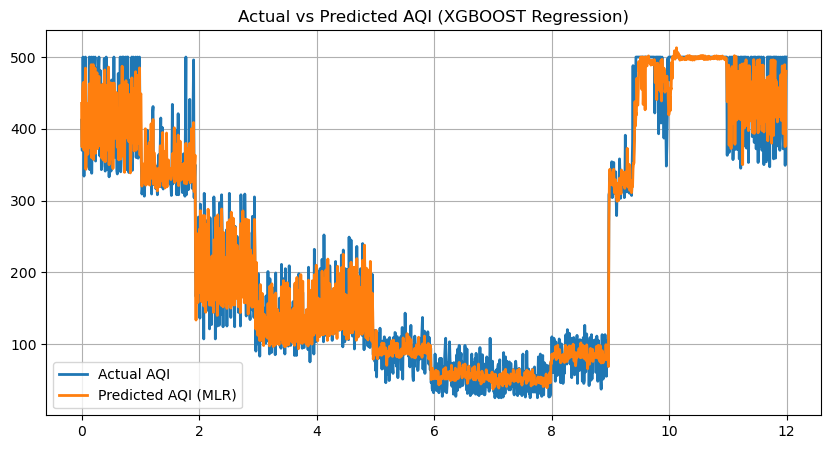

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Number of samples
n_samples = len(y_test)

# Convert samples to months (1 month = 120 samples)
x_months = np.arange(n_samples) / 121.66

plt.plot(x_months,y_test.values, label="Actual AQI", linewidth=2)
plt.plot(x_months,y_pred_xgb, label="Predicted AQI (MLR)", linewidth=2)
plt.grid(True)
plt.legend()
plt.title("Actual vs Predicted AQI (XGBOOST Regression)")
plt.show()


In [26]:
train_df = df1[df1['year'] <= 2025]

X_train = train_df.drop(columns=['aqi'])
y_train = train_df['aqi']
future_2026 = df1[df1['year'] == 2025].copy()
future_2026['year'] = 2026
future_2026 = future_2026.drop(columns=['aqi'])



In [28]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error 
import numpy as np

xgb2026 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    
)

xgb2026.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


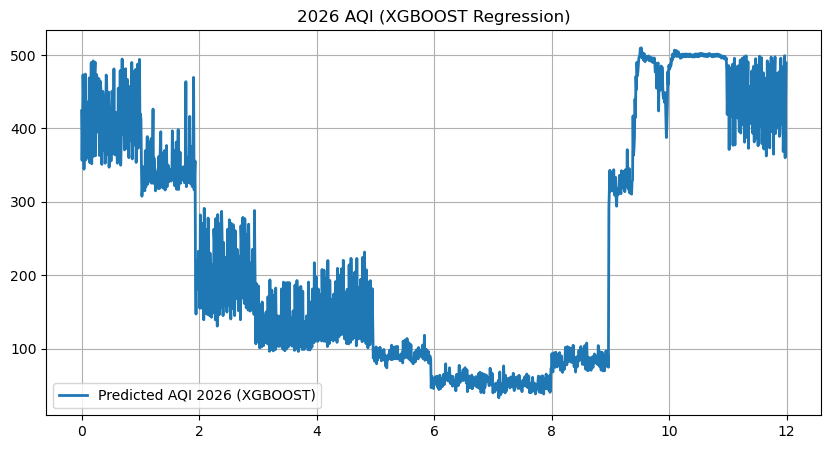

In [32]:
import matplotlib.pyplot as plt
y_pred_xgb = xgb2026.predict(future_2026)
plt.figure(figsize=(10, 5))
# Number of samples
n_samples = len(y_test)

# Convert samples to months (1 month = 120 samples)
x_months = np.arange(n_samples) / 121.66

plt.plot(x_months,y_pred_xgb, label="Predicted AQI 2026 (XGBOOST)", linewidth=2)
plt.grid(True)
plt.legend()
plt.title("2026 AQI (XGBOOST Regression)")
plt.savefig("XGB2026.jpg")
plt.show()
